<a href="https://colab.research.google.com/github/sleepyarya/PCVK-SMT5/blob/main/Week_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ===== SEL IDENTITAS =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Arya Ramadhan'  # Ganti jika ada format nama resmi lain
NIM  = '244107020195'  # Contoh: '2141720000'
N    = int(NIM[-3:])

PARAM = {
    'bins': 2**((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2**((N % 3) + 1)
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
kunci = NIM + ' ' + waktu.strftime('%Y-%m-%d')
token = hashlib.sha256(kunci.encode()).hexdigest()[:16]

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N:', N)
for k, v in PARAM.items():
    print(f'%-6s : {v}' % k)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('TOKEN  :', token)
print('SISTEM :', sys.version.split()[0], platform.platform())

NAMA   : Arya Ramadhan
NIM    : 244107020195 | N: 195
bins   : 64
clip   : 1.0
tile   : 5
L      : 2
WAKTU  : 2026-10-03 19:33:20 WIB
TOKEN  : c98d6eedc937837f
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39


In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load semua gambar dari root /content/
img_lena = cv.imread('/content/Lena.jpeg')
img_lena_lc = cv.imread('/content/lena_lc.jpeg')

ktm1a = cv.imread('/content/ruangan_gelap.jpeg')   # Gelap
ktm1b = cv.imread('/content/ruangan_terang.jpeg')  # Terang
ktm1c = cv.imread('/content/flash.jpeg')           # Flash
ktm1d = cv.imread('/content/matahari.jpeg')        # Matahari

Selisih maksimum Manual vs cv2.calcHist: 0


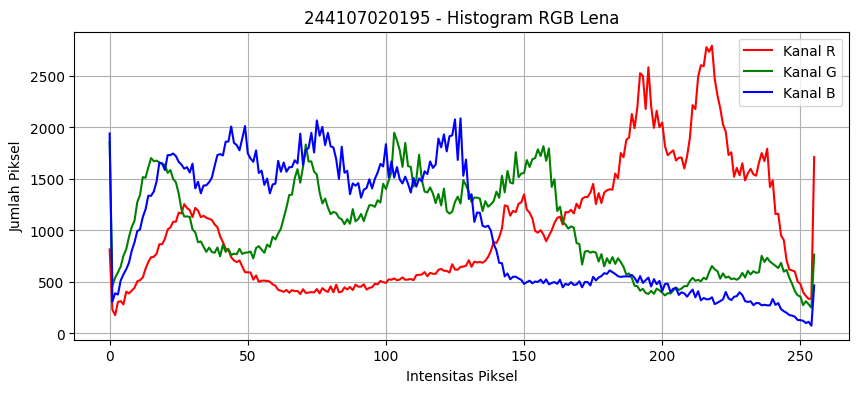

In [8]:
# Tahap 1: Verifikasi Kode dengan Lena
img_rgb = cv.cvtColor(img_lena, cv.COLOR_BGR2RGB)

# 1. Manual Looping
h_manual = np.zeros((256, 3), dtype=int)
for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        for c in range(3):
            val = img_rgb[i, j, c]
            h_manual[val, c] += 1

# 2. cv2.calcHist
h_cv = np.zeros((256, 3), dtype=int)
for c in range(3):
    hist = cv.calcHist([img_rgb], [c], None, [256], [0, 256])
    h_cv[:, c] = hist.flatten()

# Buktikan selisih maksimum = 0
diff = np.max(np.abs(h_manual - h_cv))
print(f"Selisih maksimum Manual vs cv2.calcHist: {diff}")

# Plot Histogram RGB
plt.figure(figsize=(10, 4))
colors = ('r', 'g', 'b')
for c, col in enumerate(colors):
    plt.plot(h_cv[:, c], color=col, label=f'Kanal {col.upper()}')
plt.title(NIM + ' - Histogram RGB Lena')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_2368/4233703805.py:16: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax.hist(gray.flatten(), 256, [0, 256], color='gray', alpha=0.5)


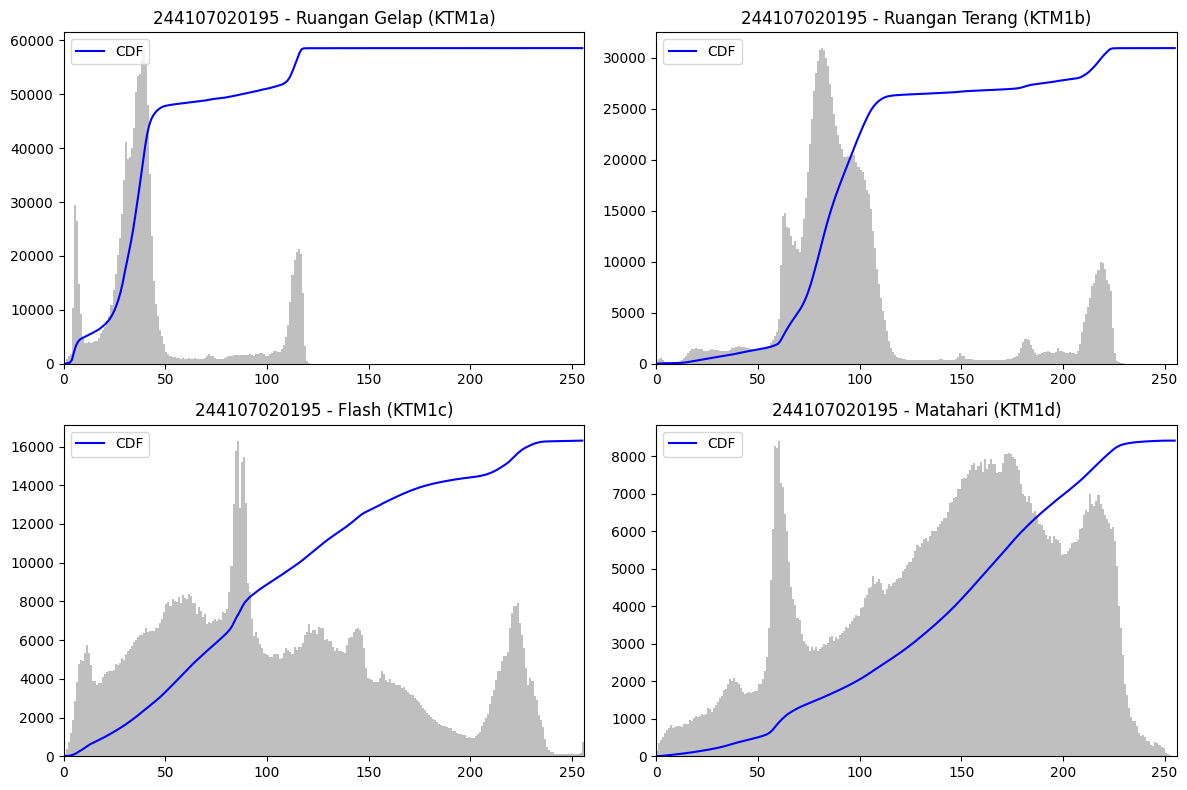

In [9]:
ktm_list = [ktm1a, ktm1b, ktm1c, ktm1d]
titles = ['Ruangan Gelap (KTM1a)', 'Ruangan Terang (KTM1b)', 'Flash (KTM1c)', 'Matahari (KTM1d)']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (img, title) in enumerate(zip(ktm_list, titles)):
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    hist, _ = np.histogram(gray.flatten(), 256, [0, 256])

    # Hitung CDF
    cdf = hist.cumsum()
    cdf_normalized = cdf * float(hist.max()) / cdf.max()

    ax = axes[idx]
    ax.hist(gray.flatten(), 256, [0, 256], color='gray', alpha=0.5)
    ax.plot(cdf_normalized, color='blue', label='CDF')
    ax.set_title(f"{NIM} - {title}")
    ax.set_xlim([0, 256])
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

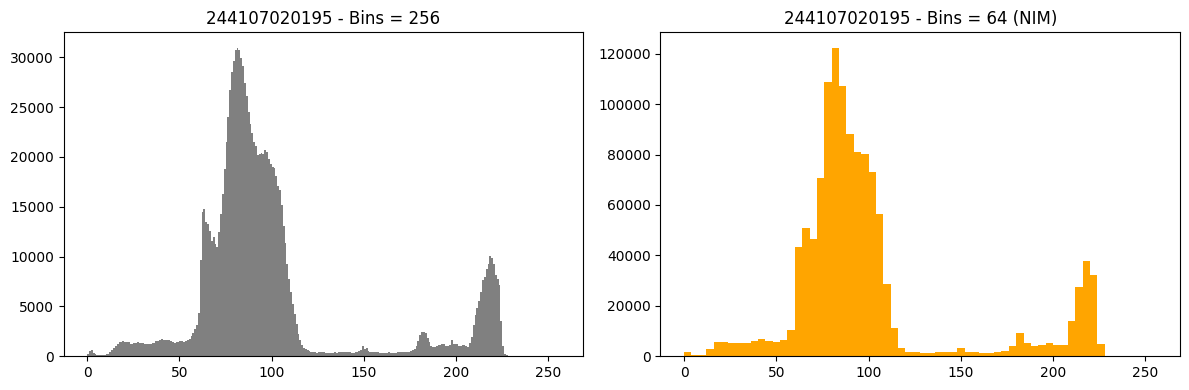

In [10]:
gray_ktm1b = cv.cvtColor(ktm1b, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 4))

# Bins Default (256)
plt.subplot(1, 2, 1)
plt.hist(gray_ktm1b.flatten(), bins=256, range=[0, 256], color='gray')
plt.title(f"{NIM} - Bins = 256")

# Bins dari Parameter NIM
plt.subplot(1, 2, 2)
plt.hist(gray_ktm1b.flatten(), bins=PARAM['bins'], range=[0, 256], color='orange')
plt.title(f"{NIM} - Bins = {PARAM['bins']} (NIM)")

plt.tight_layout()
plt.show()

PSNR Asli vs Equalized: 8.11 dB


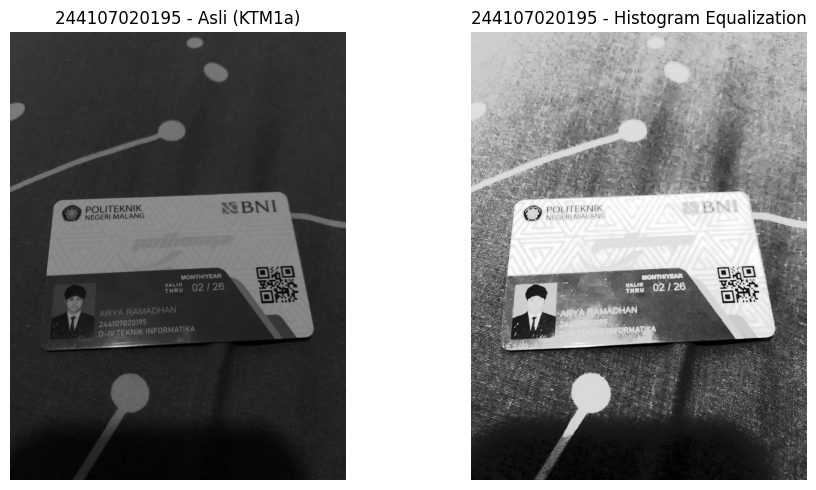

In [11]:
gray_ktm1a = cv.cvtColor(ktm1a, cv.COLOR_BGR2GRAY)
eq_ktm1a = cv.equalizeHist(gray_ktm1a)

# Hitung PSNR
psnr_val = cv.PSNR(gray_ktm1a, eq_ktm1a)
print(f"PSNR Asli vs Equalized: {psnr_val:.2f} dB")

# Tampilkan Hasil Visual
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray_ktm1a, cmap='gray')
plt.title(f"{NIM} - Asli (KTM1a)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(eq_ktm1a, cmap='gray')
plt.title(f"{NIM} - Histogram Equalization")
plt.axis('off')

plt.tight_layout()
plt.show()

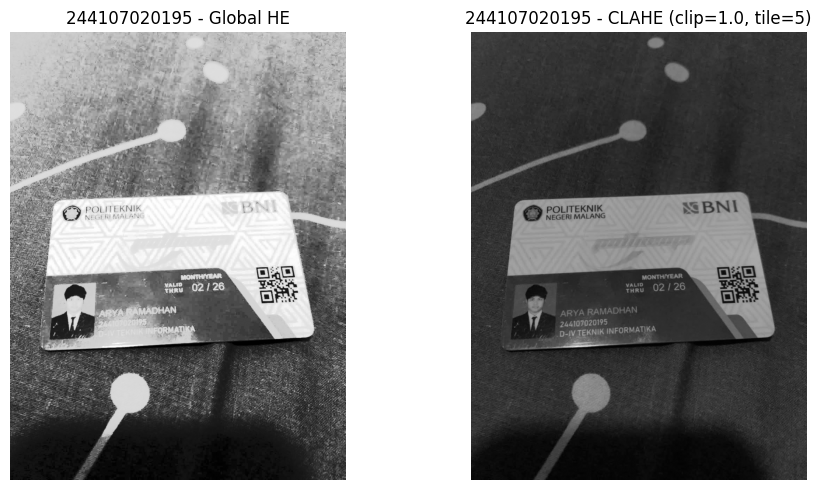

In [13]:
# Inisialisasi CLAHE pakai clipLimit dan tileGridSize dari PARAM
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
clahe_ktm1a = clahe.apply(gray_ktm1a)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(eq_ktm1a, cmap='gray')
plt.title(f"{NIM} - Global HE")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(clahe_ktm1a, cmap='gray')
plt.title(f"{NIM} - CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']})")
plt.axis('off')

plt.tight_layout()
plt.show()

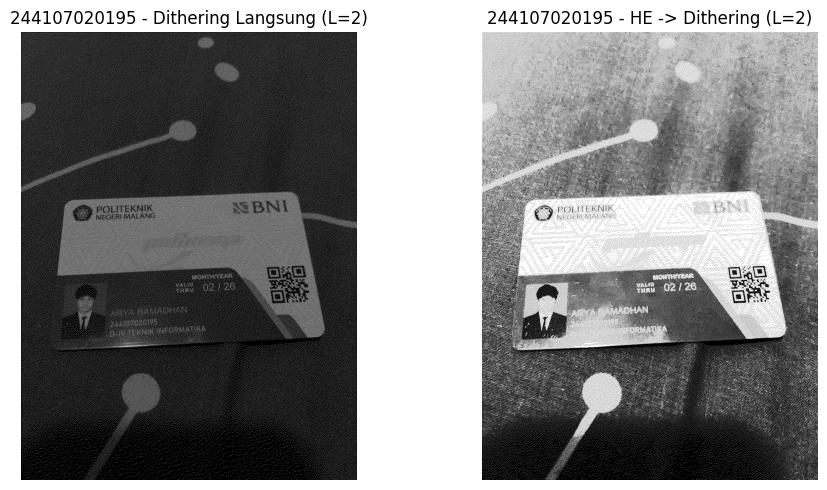

In [14]:
def floyd_steinberg(image, L=2):
    img = image.copy().astype(float)
    h, w = img.shape
    levels = np.linspace(0, 255, L)

    for y in range(h):
        for x in range(w):
            old_val = img[y, x]
            new_val = levels[np.argmin(np.abs(levels - old_val))]
            img[y, x] = new_val
            err = old_val - new_val

            if x + 1 < w:
                img[y, x + 1] += err * 7 / 16
            if y + 1 < h and x - 1 >= 0:
                img[y + 1, x - 1] += err * 3 / 16
            if y + 1 < h:
                img[y + 1, x] += err * 5 / 16
            if y + 1 < h and x + 1 < w:
                img[y + 1, x + 1] += err * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)

# 1. Dithering Langsung
dither_direct = floyd_steinberg(gray_ktm1a, L=PARAM['L'])

# 2. HE dulu baru Dithering
dither_after_he = floyd_steinberg(eq_ktm1a, L=PARAM['L'])

# Plot Hasil
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(dither_direct, cmap='gray')
plt.title(f"{NIM} - Dithering Langsung (L={PARAM['L']})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dither_after_he, cmap='gray')
plt.title(f"{NIM} - HE -> Dithering (L={PARAM['L']})")
plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
# Fungsi menghitung rata-rata pergeseran Hue
def geser_hue(img_bgr, img_eq_bgr):
    hsv_orig = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
    hsv_eq   = cv.cvtColor(img_eq_bgr, cv.COLOR_BGR2HSV)

    diff = np.abs(hsv_orig[:,:,0].astype(int) - hsv_eq[:,:,0].astype(int))
    # Mengatasi wraparound pada Hue (0-180 di OpenCV)
    diff = np.minimum(diff, 180 - diff)
    return np.mean(diff)

# 1. HE pada RGB langsung (Kanal BGR dipisah)
b, g, r = cv.split(ktm1b)
b_eq, g_eq, r_eq = cv.equalizeHist(b), cv.equalizeHist(g), cv.equalizeHist(r)
ktm_rgb_eq = cv.merge([b_eq, g_eq, r_eq])

# 2. HE pada YCrCb (Kanal Y saja)
ycrcb = cv.cvtColor(ktm1b, cv.COLOR_BGR2YCrCb)
ycrcb[:,:,0] = cv.equalizeHist(ycrcb[:,:,0])
ktm_ycrcb_eq = cv.cvtColor(ycrcb, cv.COLOR_YCrCb2BGR)

# 3. HE pada HSV (Kanal V saja)
hsv = cv.cvtColor(ktm1b, cv.COLOR_BGR2HSV)
hsv[:,:,2] = cv.equalizeHist(hsv[:,:,2])
ktm_hsv_eq = cv.cvtColor(hsv, cv.COLOR_HSV2BGR)

# 4. HE pada LAB (Kanal L saja)
lab = cv.cvtColor(ktm1b, cv.COLOR_BGR2LAB)
lab[:,:,0] = cv.equalizeHist(lab[:,:,0])
ktm_lab_eq = cv.cvtColor(lab, cv.COLOR_LAB2BGR)

# Hitung Pergeseran Hue
shift_rgb   = geser_hue(ktm1b, ktm_rgb_eq)
shift_ycrcb = geser_hue(ktm1b, ktm_ycrcb_eq)
shift_hsv   = geser_hue(ktm1b, ktm_hsv_eq)
shift_lab   = geser_hue(ktm1b, ktm_lab_eq)

print(f"Rata-rata Pergeseran Hue (KTM1b):")
print(f"1. Perataan RGB Langsung : {shift_rgb:.2f}")
print(f"2. Perataan Y (YCrCb)    : {shift_ycrcb:.2f}")
print(f"3. Perataan V (HSV)      : {shift_hsv:.2f}")
print(f"4. Perataan L (LAB)      : {shift_lab:.2f}")

Rata-rata Pergeseran Hue (KTM1b):
1. Perataan RGB Langsung : 22.18
2. Perataan Y (YCrCb)    : 0.90
3. Perataan V (HSV)      : 0.64
4. Perataan L (LAB)      : 1.52


## JAWABAN & ANALISIS PERTANYAAN MODUL 5

### Pertanyaan E-1 (Histogram & CDF)
1. **Mengapa nilai selisih maksimum antara fungsi manual dan library adalah 0?**
   * Karena logika perhitungan frekuensi intensitas piksel pada metode looping manual sama persis dengan algoritma yang digunakan oleh `cv2.calcHist` dan `np.histogram`.
2. **Bagaimana hubungan bentuk kurva CDF dengan kondisi pencahayaan?**
   * **Foto Gelap (`KTM1a`):** Kurva CDF melonjak tajam di area awal (sebelah kiri/intensitas rendah) karena mayoritas piksel bernilai gelap.
   * **Foto Terang/Flash (`KTM1c` & `KTM1d`):** Kurva CDF cenderung mendatar di awal dan baru melonjak tajam di area akhir (sebelah kanan/intensitas tinggi).
3. **Pengaruh Pengurangan Jumlah Bins:**
   * Pengurangan jumlah bins (dari 256 menjadi nilai `PARAM['bins']`) menyebabkan terjadinya pengelompokan warna yang terlalu luas, sehingga detail gradasi warna yang halus (*fine details*) menjadi hilang.

---

### Pertanyaan E-2 (Histogram Equalization & CLAHE)
1. **Mengapa nilai PSNR turun padahal gambar hasil Ekualisasi lebih jelas?**
   * PSNR mengukur tingkat kemiripan numerik antara citra asli dan citra hasil olahan. Ekualisasi histogram mereset dan meregangkan distribusi piksel secara signifikan untuk meningkatkan kontras, sehingga selisih numerik pikselnya (*MSE*) menjadi besar. Nilai PSNR yang rendah menunjukkan bahwa citra telah mengalami perubahan kontras yang besar dari aslinya, bukan berarti kualitas visualnya jelek.
2. **Ruang warna mana yang paling cocok untuk perataan warna foto KTM?**
   * Metode **YCrCb (Kanal Y)** atau **LAB (Kanal L)** paling cocok karena perataan dilakukan hanya pada kanal kecerahan tanpa merusak/menggeser warna (*Hue*) asli dari kartu KTM.

---

### Pertanyaan E-3 (Dithering Floyd-Steinberg)
1. **Perbandingan Dithering Langsung vs Ekualisasi + Dithering:**
   * Gambar yang **diekualisasi (HE/CLAHE) terlebih dahulu** lalu di-dithering menghasilkan keterbacaan teks kartu KTM yang jauh lebih baik dan jelas.
   * **Alasannya:** Dithering membatasi jumlah warna menjadi $L$ level. Jika citra aslinya gelap/pudar, detail teks akan melebur ke warna *background*. Dengan ekualisasi terlebih dahulu, kontras antara teks dan *background* dipertegas lebih dulu sebelum disederhanakan warnanya oleh Dithering.